In [1]:
import pandas as pd
import numpy as np

all_data = pd.read_csv('forest_dataset.csv')
all_data.head()
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

clf = LogisticRegression(C=1)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

accuracy_score(test_labels, y_pred)

C:\Users\dieos\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6075

In [3]:
from sklearn.model_selection import GridSearchCV
clf = LogisticRegression(solver='saga')

# init GridSearchCV with parameters
param_grid = {
    'C': np.arange(1, 5),
    'penalty': ['l1', 'l2'],
}

search = GridSearchCV(clf, param_grid, n_jobs=-1, cv=5, refit=True, scoring='accuracy')

search.fit(feature_matrix, labels)

print(search.best_params_)
accuracy_score(labels, search.best_estimator_.predict(feature_matrix))

C:\Users\dieos\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'C': np.int64(4), 'penalty': 'l2'}


C:\Users\dieos\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.6418

# Home work

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

params = {
    'n_neighbors': np.arange(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
# Train the classifier
clf_grid.fit(train_feature_matrix, train_labels)

clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}

In [7]:
optimal_clf = clf_grid.best_estimator_
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)
accuracy_score(test_labels, y_pred)

0.783

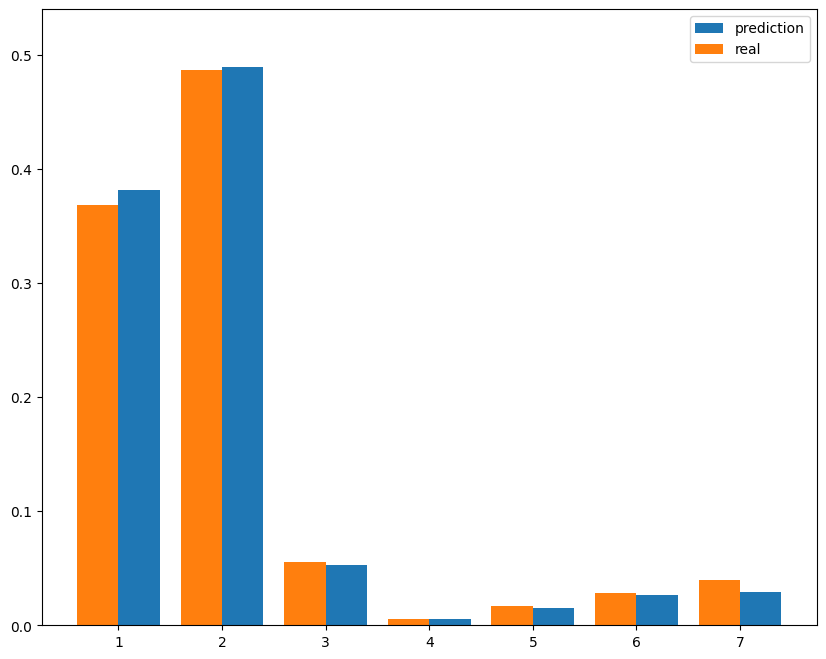

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

Для тестовой выборки с логистической регрессией точность получилась 0.64, когда для метода KNN 0.78. Значит метод ближайших соседей получил более точные к реальности результаты. Однако скорость вычисления оставляет желать лучшего. Поэтому можно сказать, что для задач, где нужна выше точность подходит KNN, а для работы с большими данными, где можно пожертвовать точностью будет лучше логистическая регрессия.

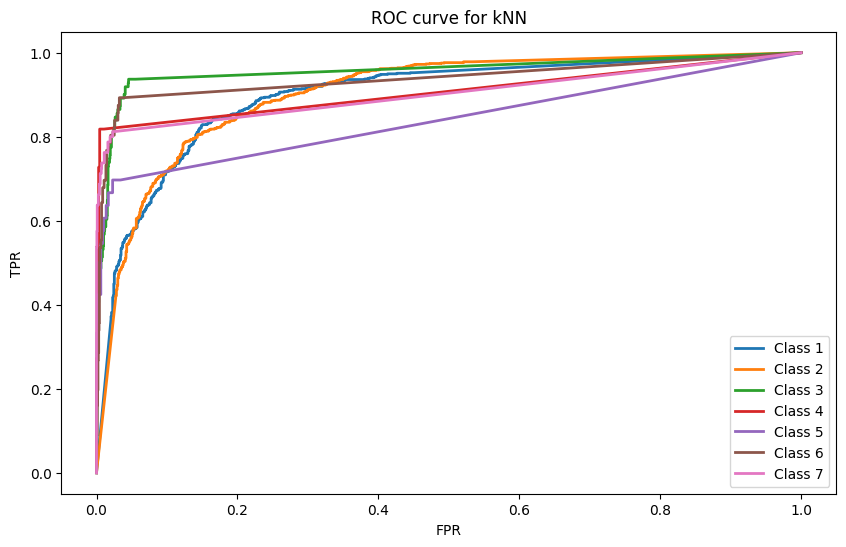

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

classes = np.unique(labels)

y_test_bin = label_binarize(test_labels, classes=classes)

plt.figure(figsize=(10, 6))

for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], pred_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]}')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for kNN')
plt.legend()
plt.show()

In [10]:
roc_auc_score(y_test_bin, pred_prob, multi_class='ovr', average='macro')

0.9063452430548241